## 15. Upskilling Recommendation Engine

**Version 1 (this notebook)**: Plain if/else rules mapping a missing skill to a training recommendation.

**Version 2 (future)**: Semantic matching using sentence-transformers (not installed for MVP).

In [1]:
import pandas as pd
import numpy as np
import os
import ast

pd.set_option('display.max_columns', None)

PROCESSED_PATH = '../data/processed'
DOCS_PATH = '../docs'

role_master = pd.read_csv(f'{PROCESSED_PATH}/role_master.csv')
employee_skills = pd.read_csv(f'{PROCESSED_PATH}/employee_skills.csv')
emp = pd.read_csv(f'{PROCESSED_PATH}/employee_attrition_processed.csv')

print(f'Employees: {emp.shape[0]}')
print(f'Employee skills: {employee_skills.shape[0]}')

Employees: 500
Employee skills: 3646


## 1. Define Training Catalog

In [2]:
training_catalog = {
    'Python': {'course': 'Python for Data Science', 'type': 'Technical', 'duration': '4 weeks'},
    'SQL': {'course': 'Advanced SQL Queries', 'type': 'Technical', 'duration': '2 weeks'},
    'AWS': {'course': 'AWS Cloud Practitioner', 'type': 'Technical', 'duration': '6 weeks'},
    'Docker': {'course': 'Docker & Containerization', 'type': 'Technical', 'duration': '3 weeks'},
    'Kubernetes': {'course': 'Kubernetes Administration', 'type': 'Technical', 'duration': '4 weeks'},
    'Git': {'course': 'Git Version Control', 'type': 'Technical', 'duration': '1 week'},
    'Java': {'course': 'Java Programming Fundamentals', 'type': 'Technical', 'duration': '8 weeks'},
    'Linux': {'course': 'Linux System Administration', 'type': 'Technical', 'duration': '4 weeks'},
    'CI/CD': {'course': 'CI/CD Pipeline Design', 'type': 'Technical', 'duration': '3 weeks'},
    'REST APIs': {'course': 'RESTful API Design', 'type': 'Technical', 'duration': '2 weeks'},
    'MLOps': {'course': 'MLOps Fundamentals', 'type': 'Technical', 'duration': '4 weeks'},
    'Machine Learning': {'course': 'Machine Learning Essentials', 'type': 'Technical', 'duration': '6 weeks'},
    'Data Analysis': {'course': 'Data Analysis with Pandas', 'type': 'Technical', 'duration': '3 weeks'},
    'Cloud': {'course': 'Cloud Architecture Fundamentals', 'type': 'Technical', 'duration': '5 weeks'},
    'Generative AI': {'course': 'Generative AI Applications', 'type': 'Technical', 'duration': '4 weeks'},
    'Microsoft Excel': {'course': 'Advanced Excel', 'type': 'Software', 'duration': '2 weeks'},
    'Microsoft Word': {'course': 'Word for Business Documents', 'type': 'Software', 'duration': '1 week'},
    'Microsoft PowerPoint': {'course': 'PowerPoint Presentations', 'type': 'Software', 'duration': '1 week'},
    'Microsoft Outlook': {'course': 'Outlook Productivity', 'type': 'Software', 'duration': '1 week'},
    'Microsoft Access': {'course': 'Access Database Basics', 'type': 'Software', 'duration': '2 weeks'},
    'Microsoft SharePoint': {'course': 'SharePoint Collaboration', 'type': 'Software', 'duration': '2 weeks'},
    'Microsoft Project': {'course': 'Project Management with MS Project', 'type': 'Software', 'duration': '3 weeks'},
    'Communication': {'course': 'Business Communication Skills', 'type': 'Soft Skill', 'duration': '2 weeks'},
    'Teamwork': {'course': 'Teamwork & Collaboration', 'type': 'Soft Skill', 'duration': '1 week'},
    'Problem Solving': {'course': 'Critical Thinking & Problem Solving', 'type': 'Soft Skill', 'duration': '2 weeks'},
    'Leadership': {'course': 'Leadership Development Program', 'type': 'Soft Skill', 'duration': '4 weeks'},
    'Negotiation': {'course': 'Negotiation Skills Workshop', 'type': 'Soft Skill', 'duration': '2 weeks'},
    'Customer Service': {'course': 'Customer Service Excellence', 'type': 'Soft Skill', 'duration': '2 weeks'},
    'Salesforce': {'course': 'Salesforce Administration', 'type': 'Domain', 'duration': '4 weeks'},
    'SAP': {'course': 'SAP Fundamentals', 'type': 'Domain', 'duration': '6 weeks'},
    'CRM': {'course': 'CRM Best Practices', 'type': 'Domain', 'duration': '2 weeks'},
    'Financial Analysis': {'course': 'Financial Analysis & Modeling', 'type': 'Domain', 'duration': '4 weeks'},
    'Recruitment': {'course': 'Recruitment & Talent Acquisition', 'type': 'Domain', 'duration': '3 weeks'},
    'Onboarding': {'course': 'Employee Onboarding Best Practices', 'type': 'Domain', 'duration': '1 week'},
    'Compliance': {'course': 'HR Compliance Training', 'type': 'Domain', 'duration': '2 weeks'},
    'Workday': {'course': 'Workday HRIS Training', 'type': 'Domain', 'duration': '3 weeks'},
    'HubSpot': {'course': 'HubSpot Marketing Platform', 'type': 'Domain', 'duration': '2 weeks'},
    'Google Analytics': {'course': 'Google Analytics Certification', 'type': 'Domain', 'duration': '3 weeks'},
    'SEO': {'course': 'Search Engine Optimization', 'type': 'Domain', 'duration': '2 weeks'},
    'Social Media': {'course': 'Social Media Marketing', 'type': 'Domain', 'duration': '2 weeks'},
    'Content Creation': {'course': 'Content Marketing Strategy', 'type': 'Domain', 'duration': '3 weeks'},
}

print(f'Training catalog: {len(training_catalog)} courses')

Training catalog: 41 courses


## 2. Version 1: Rule-Based Recommendations

In [3]:
def get_recommendation(missing_skills):
    recommendations = []
    seen = set()
    for skill in missing_skills:
        if skill in training_catalog and skill not in seen:
            c = training_catalog[skill]
            recommendations.append({
                'Missing_Skill': skill,
                'Recommended_Course': c['course'],
                'Type': c['type'],
                'Duration': c['duration']
            })
            seen.add(skill)
    return pd.DataFrame(recommendations) if recommendations else pd.DataFrame()

test_skills = ['MLOps', 'Docker', 'AWS', 'Leadership']
print('Test recommendation for:', test_skills)
print(get_recommendation(test_skills).to_string(index=False))

Test recommendation for: ['MLOps', 'Docker', 'AWS', 'Leadership']
Missing_Skill             Recommended_Course       Type Duration
        MLOps             MLOps Fundamentals  Technical  4 weeks
       Docker      Docker & Containerization  Technical  3 weeks
          AWS         AWS Cloud Practitioner  Technical  6 weeks
   Leadership Leadership Development Program Soft Skill  4 weeks


## 3. Build Employee-Level Gaps

Recalculate per-employee gaps using Department-to-Role mapping from NB13/NB14.

In [4]:
def safe_parse_list(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return val if isinstance(val, list) else []

dept_keywords = {
    'IT': ['software', 'computer', 'network', 'database', 'systems', 'developer', 'it'],
    'Sales': ['sales', 'marketing', 'advertising', 'representative', 'account'],
    'Support': ['customer', 'support', 'service', 'help', 'desk'],
    'Finance': ['finance', 'accounting', 'financial', 'analyst', 'manager'],
    'HR': ['human', 'resources', 'hr', 'training', 'development'],
    'Marketing': ['marketing', 'public', 'relations', 'communications']
}

def map_to_department(title):
    if pd.isna(title):
        return 'Other'
    title_lower = str(title).lower()
    for dept, keywords in dept_keywords.items():
        if any(kw in title_lower for kw in keywords):
            return dept
    return 'Other'

role_master['Mapped_Department'] = role_master['Title'].apply(map_to_department)

dept_required = role_master.groupby('Mapped_Department').agg({
    'Essential_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    ),
    'Software_Skills': lambda x: set(
        item for sublist in x for item in safe_parse_list(sublist)
    )
}).reset_index()
dept_required['All_Required'] = dept_required.apply(
    lambda row: row['Essential_Skills'].union(row['Software_Skills']), axis=1
)
dept_lookup = dict(zip(dept_required['Mapped_Department'], dept_required['All_Required']))

emp_skill_sets = employee_skills.groupby('EmployeeID')['current_skill'].apply(set).reset_index()
emp_skill_sets.columns = ['EmployeeID', 'Current_Skills']
emp_skill_sets = emp_skill_sets.merge(emp[['EmployeeID', 'Department']], on='EmployeeID')

emp_gaps_list = []
for _, row in emp_skill_sets.iterrows():
    dept = row['Department']
    current = row['Current_Skills']
    required = dept_lookup.get(dept, set())
    gap = required - current
    emp_gaps_list.append({
        'EmployeeID': row['EmployeeID'],
        'Department': dept,
        'Skill_Gap': list(gap),
        'Gap_Count': len(gap)
    })

emp_gaps_df = pd.DataFrame(emp_gaps_list)
print(f'Employee-level gaps: {len(emp_gaps_df)} employees')
print(f'Average gap: {emp_gaps_df["Gap_Count"].mean():.0f} skills')

Employee-level gaps: 500 employees
Average gap: 969 skills


## 4. Generate Recommendations for All Employees

In [5]:
all_recommendations = []
for _, row in emp_gaps_df.iterrows():
    recs = get_recommendation(row['Skill_Gap'])
    if not recs.empty:
        recs['EmployeeID'] = row['EmployeeID']
        recs['Department'] = row['Department']
        all_recommendations.append(recs)

recs_df = pd.concat(all_recommendations, ignore_index=True)
print(f'Generated {len(recs_df)} recommendations for {recs_df["EmployeeID"].nunique()} employees')

Generated 4983 recommendations for 500 employees


## 5. Summary Statistics

In [6]:
print('Top 15 Recommended Courses:')
print(recs_df['Recommended_Course'].value_counts().head(15).to_string())
print()
print('Recommendations by Type:')
print(recs_df['Type'].value_counts().to_string())
print()
print('Recommendations by Department:')
print(recs_df['Department'].value_counts().to_string())

Top 15 Recommended Courses:
Recommended_Course
SharePoint Collaboration              500
Project Management with MS Project    500
PowerPoint Presentations              500
Outlook Productivity                  500
Access Database Basics                500
Python for Data Science               464
Linux System Administration           460
Google Analytics Certification        374
Docker & Containerization             234
Kubernetes Administration             227
SAP Fundamentals                      205
Advanced Excel                        201
Word for Business Documents           186
Git Version Control                   132

Recommendations by Type:
Type
Software     2887
Technical    1517
Domain        579

Recommendations by Department:
Department
Sales        1068
IT           1008
Finance       860
HR            747
Marketing     657
Support       643


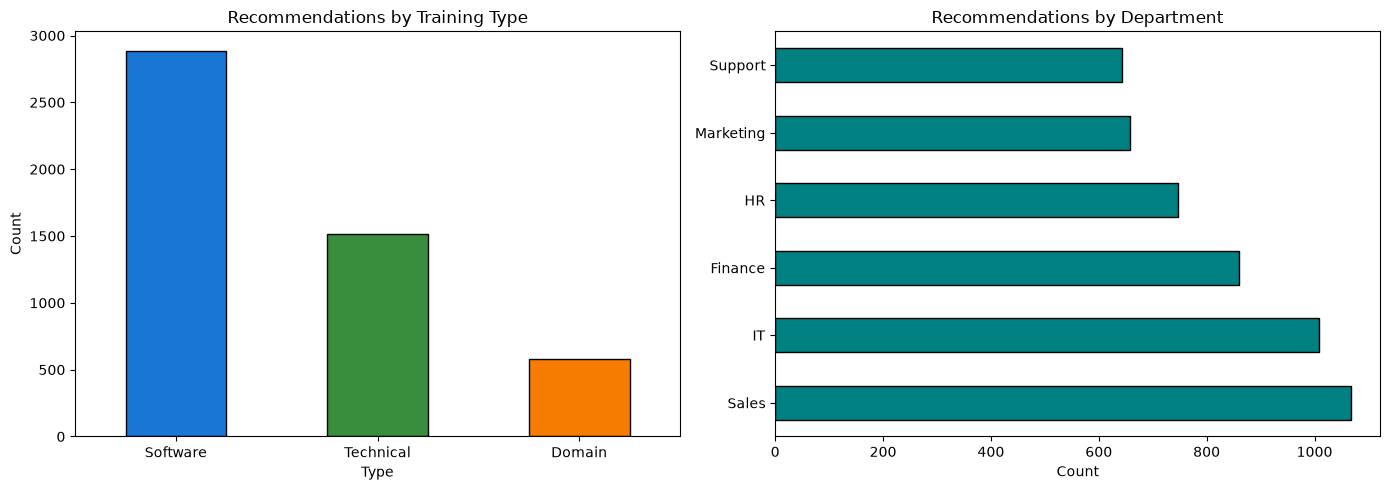

Saved: ../docs/training_recommendations.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = recs_df['Type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color=['#1976d2', '#388e3c', '#f57c00', '#d32f2f'], edgecolor='black')
axes[0].set_title('Recommendations by Training Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

dept_counts = recs_df['Department'].value_counts()
dept_counts.plot(kind='barh', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_title('Recommendations by Department')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{DOCS_PATH}/training_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {DOCS_PATH}/training_recommendations.png')

## 6. Save Recommendations

In [8]:
recs_df.to_csv(f'{PROCESSED_PATH}/employee_recommendations.csv', index=False)
print(f'Saved employee_recommendations.csv: {recs_df.shape}')

Saved employee_recommendations.csv: (4983, 6)


## Summary

### Version 1: Rule-Based
- Simple if/else mapping: missing skill -> training course
- Covers 40+ skills across Technical, Software, Soft Skill, and Domain types

### Version 2 (Future)
- Semantic matching using sentence-transformers
- Requires `sentence-transformers` library (not installed for MVP)

### Files Created
- `data/processed/employee_recommendations.csv`
- `docs/training_recommendations.png`